In [1]:
import pandas as pd
import numpy as np
#from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

In [2]:
# Model parameters
N = 100000 # Total population in 2010
mu = 0#1/(70*365);  # Natural mortality rate per day
pi = 0#mu*N  # Birth rate per day
beta = 0.0007 # Transmission rate
eps = 0.024 # 6 weeks #0.2     # Progression from E to I- 5 days
eta_0 = 1/15 #0.33 #0.0071  # baseline care seeking delay, 3 days
p = 0.8     # Proportion seeking L
k_l = 1/2  # The base screening delay at L, 2 days
k_h = 1  # The base diagnosis delay at H, 2 hours= 1/12 days
gamma_l = 0.6 #0.7      # Sensitivity of smear microscopy
q_h = 0.8      # Sensitivity of GeneXpert
alpha = 0.005  # Treatment recovery rate 1/180 
sigma = 0#1/(0.5*365) #0.03  # Immunity loss, after 18 months
phi = 1/30 #0.1   # Re-entry from F to I, assumed 1 month
phi2 = 1/90
mu_TB = 0.01 # # TB-specific mortality rate-> assumed
lamda = 0.9
xi = 0.7
max_T = 1
surges = 1
omega0 = 1
# C_L = 10   # Capacity of L (tests/day) for two Smear microscopy
# C_H = 5 #500   # Capacity of H (tests/day)
D_max = 15   # Maximum delay (days)
Diagnosis_D_max = 7 # maximum diagnosis delay, assumed 1 days
Screening_D_max = 7 # maximum screening delay, assumed 2 days

d1, d2, d3, d4 =  0.001, 0.001, 0.001, 0.001


In [3]:
# Initial conditions
I0 = 10   # Initial infected cases
S0 = N - I0
E0 = 0
L0 = 0
H0 = 0
T0 = 0
F0 = 0
R0 = 0
D0 = 0
New_cases0 = 0
New_treated = 0
state0 = [S0, E0, I0, L0, H0, T0, F0, R0, New_cases0, New_treated, D0]

# Time vector
t = np.linspace(0, max_T*365, max_T*365)  # 1 year

In [4]:
demand_amplitude = 1
def initial_delay_function(C, Q, D_max, theta=0.5):
    x = np.clip(theta * (C - Q), -500, 500)
    return D_max / (1 + np.exp(x))

def diagnosis_delay_function(C, Q, D_max_d, theta=0.5):
    x = np.clip(theta * (C - Q), -500, 500)
    return D_max_d / (1 + np.exp(x))

# Effective rate with delay
def effective_rate(base_rate, D):
    return base_rate / (1 + base_rate * D)

# def beta_t(t, beta0, surges=1, demand_amplitude = 1):
    
#     return beta0 * (1 + demand_amplitude * np.sin(2 * np.pi * surges  * t/365 - np.pi/3))   

# TB model ODEs
def tb_model( t, state, params):
    
    S, E, I, L, H, T, F, R, New_cases, New_treated, D  = state
    
    NN = S + E + I + H + L + F + T + R + D
    
    
    
    eps, eta_0, p, gamma_l, k_h, k_l,  q_h, alpha, phi, mu_TB, C_L, C_H, omega0, D_max, Diagnosis_D_max, Screening_D_max, beta, lamda, xi, demand_amplitude, surges, d1, d2, d3 = params


    FOI = beta*(I + xi*(H + L) + F + D)/(1 + lamda*(I + xi*(H + L) + F + D))

    omega = omega0* (p*eta_0 * I/NN) * (S+E+R)
    
    # Demands
    Q_L = p*eta_0 * I + omega #*(1 + demand_amplitude * np.sin(2 * np.pi * surges  * t/365 - np.pi/2) )
    Q_H = (1 - p) * eta_0* I  + gamma_l *k_l* L #(1 + demand_amplitude * np.sin(2 * np.pi * surges  * t/365 - np.pi/2) )
    
    # Initial care seeking Delays
    D_L_initial = initial_delay_function(C_L, Q_L, D_max)
    D_H_initial = initial_delay_function(C_H, Q_H, D_max)

    #Screening/Diagnosis delay
    D_L_screeing = diagnosis_delay_function(C_L, Q_L, Screening_D_max)
    D_H_daignosis = diagnosis_delay_function(C_H, Q_H, Diagnosis_D_max)

    # initial patiend care-seeking delay rate
    eta_L = effective_rate(eta_0, D_L_initial)
    eta_H = effective_rate(eta_0, D_H_initial)
   

    #Screening/Diagnosis delay rate
    k_L = effective_rate(k_l, D_L_screeing)
    k_H =  effective_rate(k_h, D_H_daignosis)

    new_L = p * eta_L 
    new_H = (1 - p) * eta_H 

    #L_to_H = k_L* (1 + demand_amplitude * np.sin(2 * np.pi * 3 * t/365 - np.pi/2))
    
    # ODEs
    dSdt = -FOI* S  
    dEdt = FOI * S  - eps* E
    dIdt = eps * E - (new_L + new_H ) * I + (1-d1)*phi * F + phi2*D - mu_TB * I 
    dLdt = new_L * I - (1-d2)*k_L * L -  mu_TB* L - d2*L
    dHdt = new_H * I + (1-d2)*k_L*gamma_l * L - (1-d3)*k_H * H - mu_TB * H - d3*H
    dTdt = (1-d3)*q_h * k_H * H - alpha * T
    dFdt = (1-d2)*(1 - gamma_l) * k_L * L + (1-d3)*(1 - q_h) * k_H * H - ((1-d1)*phi + mu_TB + d1) * F 
    dRdt = alpha * T 
    dNewCases = FOI * S 
    dNewTreated = (1-d3)*q_h * k_H * H
    dDdt = d1*F + d2*L + d3* H - (phi2 + mu_TB)*D
    
    
    return [dSdt, dEdt, dIdt, dLdt, dHdt, dTdt, dFdt, dRdt, dNewCases, dNewTreated, dDdt]

In [5]:
a1  =  initial_delay_function(120, 0, 90)
b1 = effective_rate(eta_0, a1)
print('b1 = ', b1)

a2  =  initial_delay_function(60, 0, 90)
b2 = effective_rate(eta_0, a2)
print('b2 = ', b2)

a3  =  initial_delay_function(30, 0, 90)
b3 = effective_rate(eta_0, a3)
print('b3 = ', b3)

b1 =  0.06666666666666667
b2 =  0.06666666666662922
b3 =  0.06666654430600048


In [6]:
# Define scenarios
scenarios = {
    "No capacity constraint": {"C_L": 300, "C_H": 64},
    
    "Moderate capacity constraint": {"C_L": 200, "C_H": 32},
    
    "High capacity constraint": {"C_L": 100, "C_H": 16}
    
}


# Store summary statistics
results = {}
# all_L_demand_results = {}
# all_H_demand_results = {}
# all_L_care_seeking_rates = {}
# all_H_care_seeking_rates = {}
# all_H_Diagnosis_rates = {}
# all_L_Screening_rates = {}
# all_Beta_values = {}
# all_daily_cases = {}
# all_daily_new_cases = {}
# Simulate each scenario
for scenario_name, param_dict in scenarios.items():
        
    param_tuple = (eps, eta_0, p, gamma_l, k_h, k_l,  q_h, alpha, phi, mu_TB, param_dict['C_L'], param_dict["C_H"],
                   omega0, D_max, Diagnosis_D_max, Screening_D_max, beta, lamda, xi, demand_amplitude, surges, d1, d2, d3)

    sol = solve_ivp(
        tb_model,
        [t[0], t[-1]],
        state0,
        method = 'LSODA',
        t_eval = t,
        args = (param_tuple,),
        max_step = 0.5,
        rtol = 1e-6, atol = 1e-8
    ) 


    S, E, I, L, H, T, F, R,NewCases, NewTreated, D = sol.y

    TP = S + E + I + L + H + T + F + R + D

    Presumptive_individuals = omega0* (p*eta_0 * I/TP) * (S+E+R) 
    
    Q_L = p * eta_0 * I + Presumptive_individuals #*(1 + demand_amplitude * np.sin(2 * np.pi * surges * i/365 - np.pi/2))
    Q_H = (1 - p) * eta_0 * I + gamma_l *k_l* L #*(1 + demand_amplitude * np.sin(2 * np.pi * surges  * i/365 - np.pi/2)) 

    D_L_initial = initial_delay_function(param_dict['C_L'], Q_L, D_max)
    D_H_initial = initial_delay_function(param_dict["C_H"], Q_H, D_max)

    
    # Initial diagnosis and screening Delays
    Screening_initial = diagnosis_delay_function(param_dict["C_L"], Q_L, Screening_D_max)
    Diagnosis_initial = diagnosis_delay_function(param_dict['C_H'], Q_H, Diagnosis_D_max )

    Care_seeking_rate_L = effective_rate(eta_0, D_L_initial)
    Care_seeking_rate_H = effective_rate(eta_0, D_H_initial)
    diagnosis_rate = effective_rate(k_h, Diagnosis_initial)
    screening_rate = effective_rate(k_l, Screening_initial)

    #prevalence_sum = np.cumsum(I)

    betas = np.zeros(len(t))
    for i in range(len(t)):
        betas[i]  = beta 
        
    label =  f"{scenario_name}"
    results[label] = { 'Infectives' : I + xi*(H + L) + F + D,
                       'force_of_infection': beta*(I + xi*(H + L) + F + D)/(1+ lamda*(I + xi*(H + L) + F + D)),
                      'cum_cases' : NewCases,
                      'prevalence_I': I,
                      'treated_T': T,
                      'prevalence_H': H,
                       'prevalence_L': L,
                       'prevalence_D': D,
                       'cum_prevalence':I + D,
                      'cum_treated': NewTreated,
                      'demand_at_L' : Q_L,
                      'demand_at_H' : Q_H,
                      'delayed_care_seeking_rate_at_L':  Care_seeking_rate_L,
                      'delayed_care_seeking_rate_at_H' : Care_seeking_rate_H,
                      'delayed_screening_rate' : screening_rate,
                      'delayed_diagnosis_rate' : diagnosis_rate,
                      'transmission_rate': betas,
                      'presumptive_TB': Presumptive_individuals

                     }
    
    # Compute demands and care-seeking rates 
    # Q_L_vals = np.zeros(len(t))
    # Q_H_vals = np.zeros(len(t))
    # #Care-seeking rate
    # Care_seeking_rate_L = np.zeros(len(t))
    # Care_seeking_rate_H = np.zeros(len(t))
    # beta_t_values = np.zeros(len(t))
    # diagnosis_rate = np.zeros(len(t))
    # screening_rate = np.zeros(len(t))
    # Daily_cases = np.zeros(len(t))
    # betas = np.zeros(len(t))
    # for i in range(len(t)):
    #     S, E, I, L, H, T, F, R,NewCases = sol.y[:, i]
        
    #     beta  = beta_t(i,  beta_0)
    #     FOI = beta*(I + xi*(H + L) + F)/(1+ lamda*(I + xi*(H + L) + F))
    #     daily_case = FOI*S
    #     # Demands
    #     Q_L = p * eta_0 * I #*(1 + demand_amplitude * np.sin(2 * np.pi * surges * i/365 - np.pi/2))
    #     Q_H = (1 - p) * eta_0 * I + gamma_l *k_l* L #*(1 + demand_amplitude * np.sin(2 * np.pi * surges  * i/365 - np.pi/2)) 
        
    #     Q_L_vals[i] = Q_L
    #     Q_H_vals[i] = Q_H

    #     # Initial care seeking  Delays
    #     D_L_initial = initial_delay_function(param_dict['C_L'], Q_L, D_max)
    #     D_H_initial = initial_delay_function(param_dict["C_H"], Q_H, D_max)
        
    #     # Initial diagnosis and screening Delays
    #     Screening_initial = diagnosis_delay_function(param_dict["C_L"], Q_L, Screening_D_max)
    #     Diagnosis_initial = diagnosis_delay_function(param_dict['C_H'], Q_H, Diagnosis_D_max )
        
        
    #     Care_seeking_rate_L[i] = effective_rate(eta_0, D_L_initial)
    #     Care_seeking_rate_H[i] = effective_rate(eta_0, D_H_initial)
    #     diagnosis_rate[i] = effective_rate(k_h, Diagnosis_initial)
    #     screening_rate[i] = effective_rate(k_l, Screening_initial)
    #     Daily_cases[i] = daily_case
    #     betas[i] = beta
    


    # label =  f"{scenario_name}"
    # print(f'Max prevalence_{scenario_name} = ', max(sol.y[2] + sol.y[3] + sol.y[4] + sol.y[6]))
    # print(f'Min patient delay at L_{scenario_name} = ', min(Care_seeking_rate_L))
    # print(f'Min patient delay at H_{scenario_name} = ', min(Care_seeking_rate_H))
    # print(f'Min screening delay_{scenario_name} = ', min(screening_rate))
    # print(f'Min diagnosis delay_{scenario_name} = ', min(diagnosis_rate))

    # results[label] = { 'daily_new_cases' : sol.y[2] + sol.y[3] + sol.y[4] + sol.y[6],
    #                   'cum_cases' : sol.y[8],
    #                   'demand_at_L' : Q_L_vals,
    #                   'demand_at_H' : Q_H_vals,
    #                   'delayed_care_seeking_rate_at_L':  Care_seeking_rate_L,
    #                   'delayed_care_seeking_rate_at_H' : Care_seeking_rate_H,
    #                   'delayed_screening_rate' : screening_rate,
    #                   'delayed_diagnosis_rate' : diagnosis_rate,
    #                   'transmission_rate': betas

    #                  }


Text(0, 0.5, 'Presumptive TB')

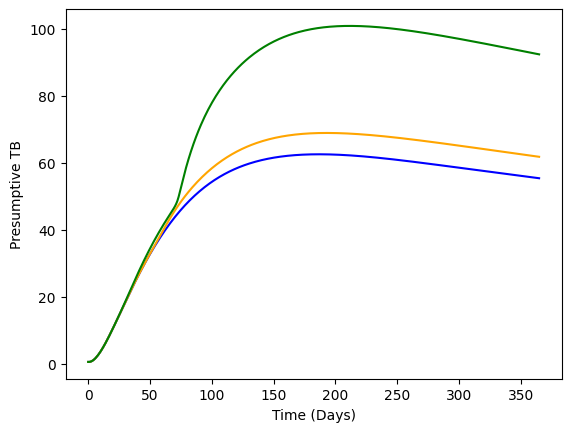

In [7]:
colors = ['blue', 'orange', 'green']
for j, scenario_name in enumerate(scenarios.keys()):
    label = f"{scenario_name}"
    plt.plot(t, results[label]['presumptive_TB'], color = colors[j])
plt.xlabel('Time (Days)')
plt.ylabel('Presumptive TB')

Maximum screening demand 129.61548991875867
Maximum diagnosis demand 56.208137717318664
min delayed_care_seeking_rate_at_H when_0_ 0.0653646302756227
max delayed_care_seeking_rate_at_H when_0_ 0.06666666666666576
Cumulative treated_j =  13206.900446795456
final care-seekers prevalence =  1258.1854091938008
Maximum screening demand 142.81442819049994
Maximum diagnosis demand 61.924585496172014
min delayed_care_seeking_rate_at_H when_1_ 0.03333333862762061
max delayed_care_seeking_rate_at_H when_1_ 0.06666665864711867
Cumulative treated_j =  11327.523135027546
final care-seekers prevalence =  1386.1416641349338
Maximum screening demand 209.3324471853366
Maximum diagnosis demand 160.3993493094621
min delayed_care_seeking_rate_at_H when_2_ 0.03333333333333333
max delayed_care_seeking_rate_at_H when_2_ 0.06664277785776854
Cumulative treated_j =  9104.932127681921
final care-seekers prevalence =  2033.7571396390756


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


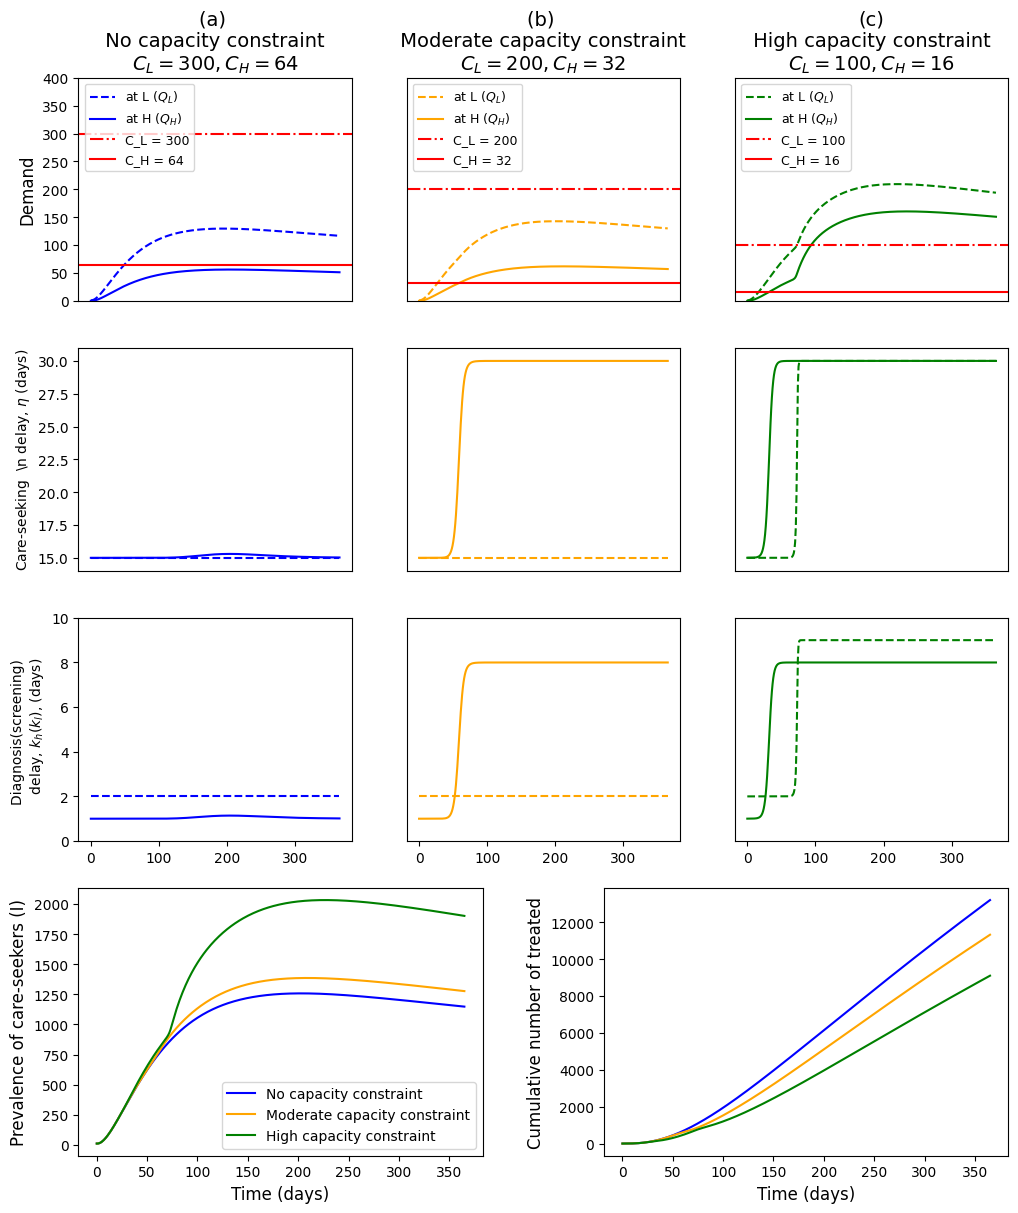

In [8]:
fig = plt.figure(figsize=(12, 14), constrained_layout=True)
gs = gridspec.GridSpec(4, 3, height_ratios=[1, 1, 1, 1.2], hspace=0.2)

colors = ['blue', 'orange', 'green']
titles = ['(a) \n No capacity constraint \n' + rf'$C_L = {scenarios["No capacity constraint"]["C_L"]}, C_H = {scenarios["No capacity constraint"]["C_H"]}$' ,
          '(b) \n Moderate capacity constraint \n' + rf'$ C_L = {scenarios["Moderate capacity constraint"]["C_L"]}, C_H = {scenarios["Moderate capacity constraint"]["C_H"]}$',
          '(c)\n High capacity constraint \n' + rf'$ C_L = {scenarios["High capacity constraint"]["C_L"]}, C_H = {scenarios["High capacity constraint"]["C_H"]}$' ]

gs_last = gs[3, :].subgridspec(1, 2, wspace=0.3)

ax30 = fig.add_subplot(gs_last[0])  # left
ax3  = fig.add_subplot(gs_last[1])  # right

# ax3 = fig.add_subplot(gs[3, 1:3 ])
# ax30 = fig.add_subplot(gs[3, 0])
# --- Plot 1 ---
for j, scenario_name in enumerate(scenarios.keys()):
    label = f"{scenario_name}"
    
    # --- Plot 1 ---
    ax0 = fig.add_subplot(gs[0, j])
    ax0.plot(t, results[label]['demand_at_L'], label = 'at L ($Q_L$)', linestyle = '--', color=colors[j])
    ax0.plot(t, results[label]['demand_at_H'], label = 'at H ($Q_H$)', color=colors[j])
    ax0.axhline(y=scenarios[scenario_name]['C_L'], linestyle='-.', color= 'red', label=f"C_L = {scenarios[scenario_name]['C_L']}")
    ax0.axhline(y=scenarios[scenario_name]['C_H'], label=f"C_H = {scenarios[scenario_name]['C_H']}", color='red')
    ax0.set_title(titles[j],  fontsize=14)
    print('Maximum screening demand', max(results[label]['demand_at_L']))
    print('Maximum diagnosis demand', max(results[label]['demand_at_H']))
    
    ax0.set_xticks([])
    ax0.set_ylim([0, 400])
    ax0.legend(fontsize = 9, loc='upper left')
    if j == 0:
        ax0.set_ylabel("Demand", fontsize=12)
    if j != 0:
        ax0.set_yticks([])
        

    # --- Plot 2 ---
    ax1 = fig.add_subplot(gs[1, j])
    ax1.plot(t,1/results[label]['delayed_care_seeking_rate_at_L'], label = 'at L ($k_l$)', linestyle = '--', color=colors[j])
    ax1.plot(t, 1/results[label]['delayed_care_seeking_rate_at_H'], label = 'at H ($k_h$)', color=colors[j])
    print(f'min delayed_care_seeking_rate_at_H when_{j}_', np.min( results[label]['delayed_care_seeking_rate_at_H']))
    print(f'max delayed_care_seeking_rate_at_H when_{j}_', np.max( results[label]['delayed_care_seeking_rate_at_H']))
    
    ax1.set_xticks([])
    
    ax1.set_ylim([14, 31])
    
    #ax2.set_ylim([0, 8000])
    if j == 0:
    
        ax1.set_ylabel(r"Care-seeking  \n delay, $\eta$ (days)", fontsize=10)
        
    if j != 0:
        ax1.set_yticks([])

    # --- Plot 3 ---
    
    ax2 = fig.add_subplot(gs[2, j])
    ax2.plot(t,1/results[label]['delayed_screening_rate'], label = 'Low quality', linestyle = '--', color=colors[j])
    ax2.plot(t, 1/results[label]['delayed_diagnosis_rate'], label = 'High quality', color=colors[j])
    
    ax2.set_ylim([0, 10])
    if j == 0:
        ax2.set_ylabel("Diagnosis(screening) \n  delay, $k_h (k_l)$, (days)", fontsize=10)
        
        #ax2.legend()
    if j != 0:
        ax2.set_yticks([])

    #--- Plot 3 ---
    
    
    ax30.plot(t, results[label]['prevalence_I'], label=scenario_name, color=colors[j])
    ax30.legend(loc='lower right')
        
    ax3.plot(t, results[label]['cum_treated'],  color=colors[j])
    print(f'Cumulative treated_j = ', max(results[label]['cum_treated']))
    print(f'final care-seekers prevalence = ', max(results[label]['prevalence_I']))

ax30.set_xlabel("Time (days)",  fontsize = 12)
ax30.set_ylabel("Prevalence of care-seekers (I)",  fontsize = 12)

ax3.set_xlabel("Time (days)",  fontsize = 12)
ax3.set_ylabel("Cumulative number of treated",  fontsize = 12)
#ax3.legend(loc='lower right')


# # Super title and layout
# plt.suptitle("Demand, care seeking rate, and cumulative incidence by capacity scenario", fontsize=12, fontweight='bold', y=0.9)
#plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

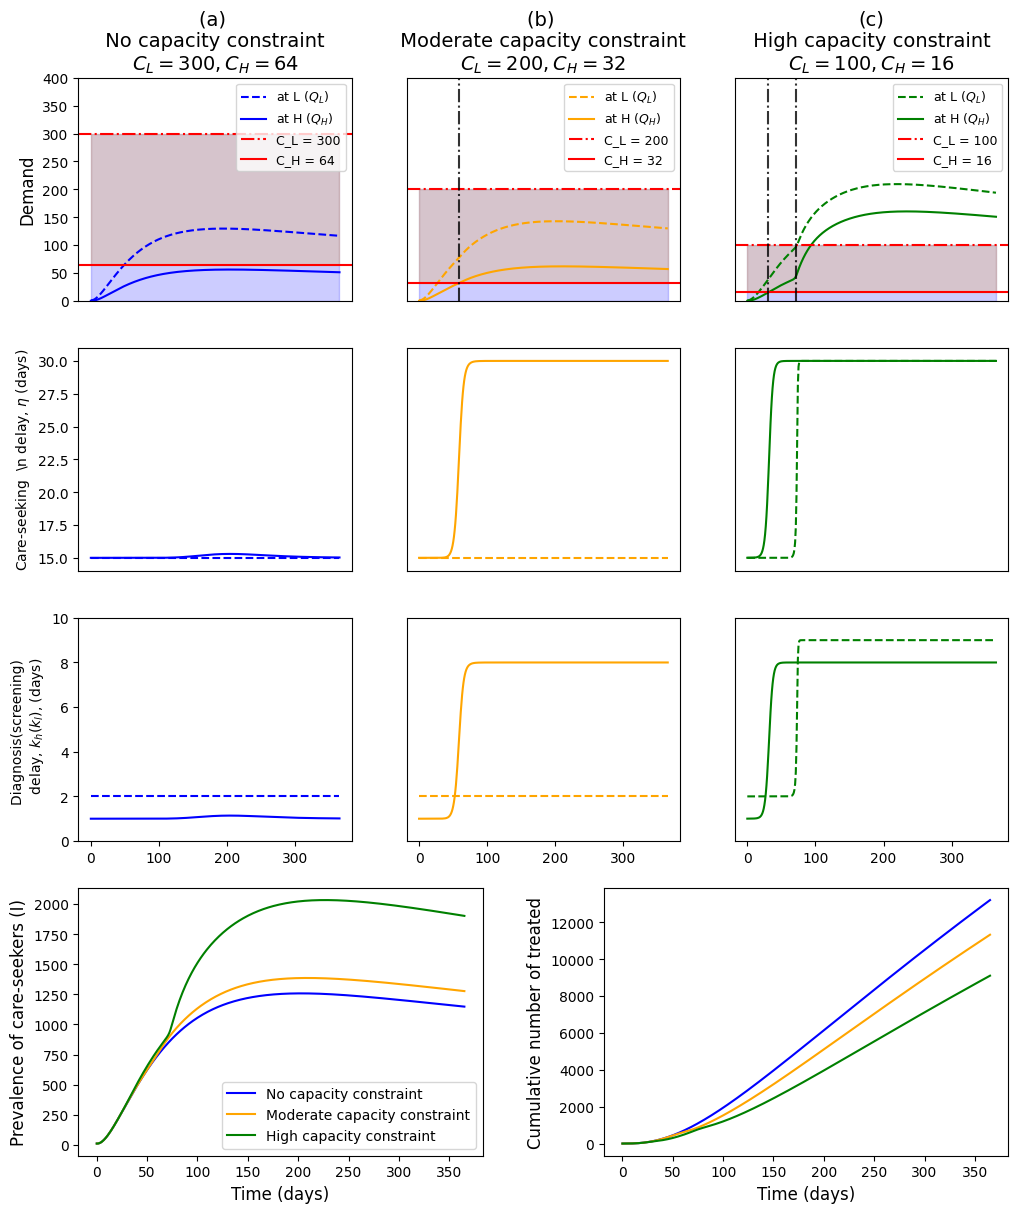

In [9]:
fig = plt.figure(figsize=(12, 14), constrained_layout=True)
gs = gridspec.GridSpec(4, 3, height_ratios=[1, 1, 1, 1.2], hspace=0.2)

colors = ['blue', 'orange', 'green']
titles = ['(a) \n No capacity constraint \n' + rf'$C_L = {scenarios["No capacity constraint"]["C_L"]}, C_H = {scenarios["No capacity constraint"]["C_H"]}$' ,
          '(b) \n Moderate capacity constraint \n' + rf'$ C_L = {scenarios["Moderate capacity constraint"]["C_L"]}, C_H = {scenarios["Moderate capacity constraint"]["C_H"]}$',
          '(c)\n High capacity constraint \n' + rf'$ C_L = {scenarios["High capacity constraint"]["C_L"]}, C_H = {scenarios["High capacity constraint"]["C_H"]}$' ]

gs_last = gs[3, :].subgridspec(1, 2, wspace=0.3)

ax30 = fig.add_subplot(gs_last[0])  # left
ax3  = fig.add_subplot(gs_last[1])  # right

# ax3 = fig.add_subplot(gs[3, 1:3 ])
# ax30 = fig.add_subplot(gs[3, 0])
# --- Plot 1 ---
for j, scenario_name in enumerate(scenarios.keys()):
    label = f"{scenario_name}"

    C_L = scenarios[scenario_name]['C_L']
    C_H = scenarios[scenario_name]['C_H']
    Q_L = results[label]['demand_at_L']
    Q_H = results[label]['demand_at_H']

    
    # --- Plot 1 ---
    ax0 = fig.add_subplot(gs[0, j])
    ax0.plot(t, results[label]['demand_at_L'], label = 'at L ($Q_L$)', linestyle = '--', color=colors[j])
    ax0.plot(t, results[label]['demand_at_H'], label = 'at H ($Q_H$)', color=colors[j])
    ax0.axhline(y=scenarios[scenario_name]['C_L'], linestyle='-.', color= 'red', label=f"C_L = {scenarios[scenario_name]['C_L']}")
    ax0.axhline(y=scenarios[scenario_name]['C_H'], label=f"C_H = {scenarios[scenario_name]['C_H']}", color='red')
    ax0.set_title(titles[j],  fontsize=14)

    # Shade region below C_L
    ax0.fill_between(t, 0, C_L, color='blue', alpha=0.2)
    
    # Shade region between C_L and C_H
    ax0.fill_between(t, C_L, C_H, color='orange', alpha=0.2)

    
    
    # --- Find first crossing for C_L ---
    cross_L_idx = np.where((Q_L[:-1] < C_L) & (Q_L[1:] >= C_L))[0]
    t_cross_L = t[cross_L_idx[0]] if len(cross_L_idx) > 0 else None

    # --- Find first crossing for C_HA ---
    cross_H_idx = np.where((Q_H[:-1] < C_H) & (Q_H[1:] >= C_H))[0]
    t_cross_H = t[cross_H_idx[0]] if len(cross_H_idx) > 0 else None

    if t_cross_L is not None:
        
        ax0.axvline(x=t_cross_L, color='black', linestyle='-.', alpha=0.8)

    if t_cross_H is not None:
        ax0.axvline(x=t_cross_H, color='black', linestyle='-.', alpha=0.8)
    
    ax0.set_xticks([])
    ax0.set_ylim([0, 400])
    ax0.legend(fontsize = 9, loc='upper right')
    if j == 0:
        ax0.set_ylabel("Demand", fontsize=12)
    if j != 0:
        ax0.set_yticks([])
        

    # --- Plot 2 ---
    ax1 = fig.add_subplot(gs[1, j])
    ax1.plot(t,1/results[label]['delayed_care_seeking_rate_at_L'], label = 'at L ($k_l$)', linestyle = '--', color=colors[j])
    ax1.plot(t, 1/results[label]['delayed_care_seeking_rate_at_H'], label = 'at H ($k_h$)', color=colors[j])    
    ax1.set_xticks([])
    
    ax1.set_ylim([14, 31])
    
    #ax2.set_ylim([0, 8000])
    if j == 0:
    
        ax1.set_ylabel(r"Care-seeking  \n delay, $\eta$ (days)", fontsize=10)
        
    if j != 0:
        ax1.set_yticks([])

    # --- Plot 3 ---
    
    ax2 = fig.add_subplot(gs[2, j])
    ax2.plot(t,1/results[label]['delayed_screening_rate'], label = 'Low quality', linestyle = '--', color=colors[j])
    ax2.plot(t, 1/results[label]['delayed_diagnosis_rate'], label = 'High quality', color=colors[j])
    
    ax2.set_ylim([0, 10])
    if j == 0:
        ax2.set_ylabel("Diagnosis(screening) \n  delay, $k_h (k_l)$, (days)", fontsize=10)
        
        #ax2.legend()
    if j != 0:
        ax2.set_yticks([])

    #--- Plot 3 ---
    
    
    ax30.plot(t, results[label]['prevalence_I'], label=scenario_name, color=colors[j])
    ax30.legend(loc='lower right')
        
    ax3.plot(t, results[label]['cum_treated'],  color=colors[j])

ax30.set_xlabel("Time (days)",  fontsize = 12)
ax30.set_ylabel("Prevalence of care-seekers (I)",  fontsize = 12)

ax3.set_xlabel("Time (days)",  fontsize = 12)
ax3.set_ylabel("Cumulative number of treated",  fontsize = 12)

plt.show()

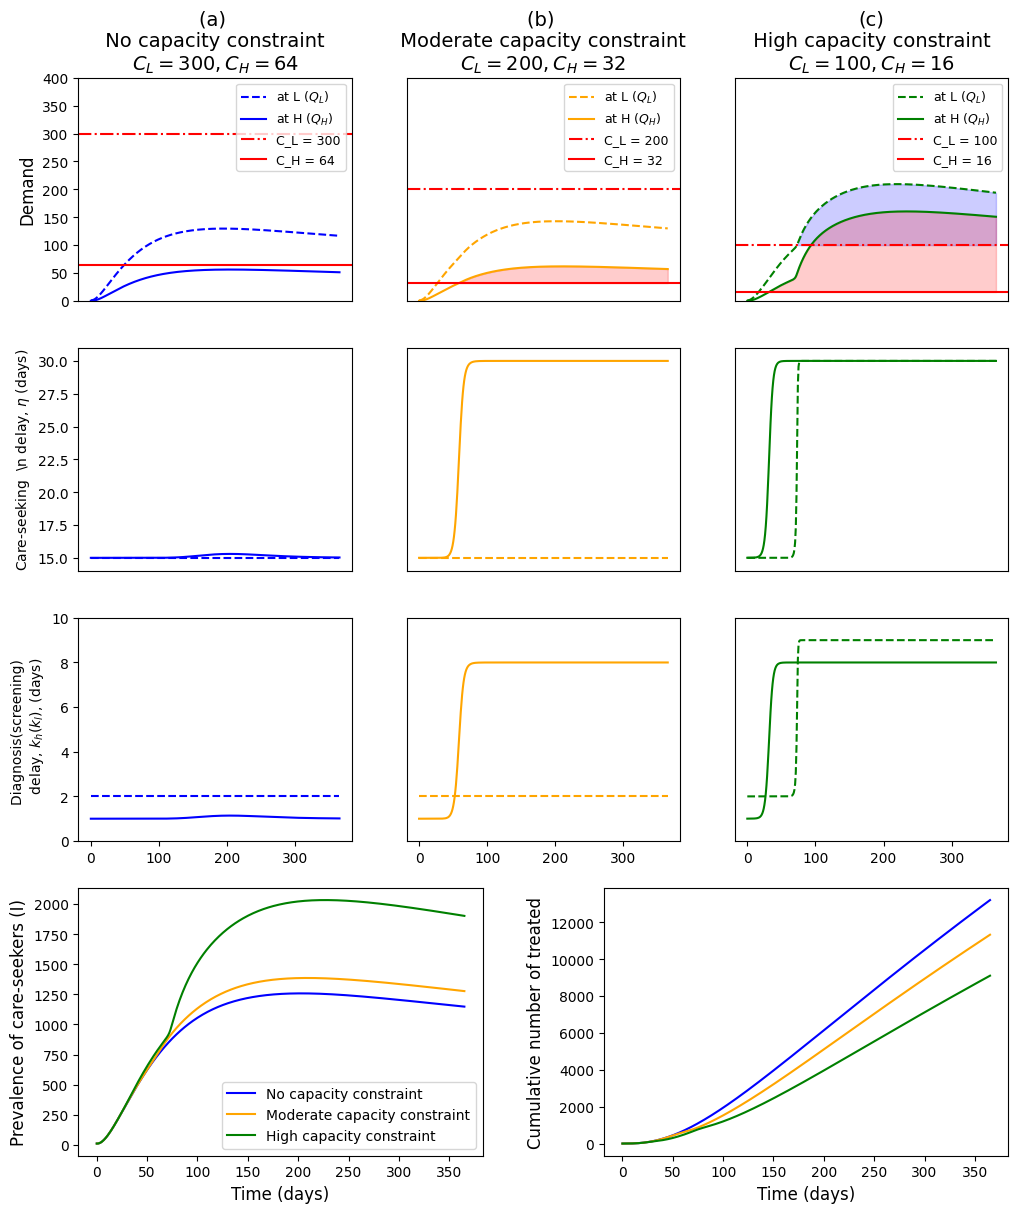

In [10]:
fig = plt.figure(figsize=(12, 14), constrained_layout=True)
gs = gridspec.GridSpec(4, 3, height_ratios=[1, 1, 1, 1.2], hspace=0.2)

colors = ['blue', 'orange', 'green']
titles = ['(a) \n No capacity constraint \n' + rf'$C_L = {scenarios["No capacity constraint"]["C_L"]}, C_H = {scenarios["No capacity constraint"]["C_H"]}$' ,
          '(b) \n Moderate capacity constraint \n' + rf'$ C_L = {scenarios["Moderate capacity constraint"]["C_L"]}, C_H = {scenarios["Moderate capacity constraint"]["C_H"]}$',
          '(c)\n High capacity constraint \n' + rf'$ C_L = {scenarios["High capacity constraint"]["C_L"]}, C_H = {scenarios["High capacity constraint"]["C_H"]}$' ]

gs_last = gs[3, :].subgridspec(1, 2, wspace=0.3)

ax30 = fig.add_subplot(gs_last[0])  # left
ax3  = fig.add_subplot(gs_last[1])  # right

# ax3 = fig.add_subplot(gs[3, 1:3 ])
# ax30 = fig.add_subplot(gs[3, 0])
# --- Plot 1 ---
for j, scenario_name in enumerate(scenarios.keys()):
    label = f"{scenario_name}"

    C_L = scenarios[scenario_name]['C_L']
    C_H = scenarios[scenario_name]['C_H']
    Q_L = results[label]['demand_at_L']
    Q_H = results[label]['demand_at_H']

    
    # --- Plot 1 ---
    ax0 = fig.add_subplot(gs[0, j])
    ax0.plot(t, results[label]['demand_at_L'], label = 'at L ($Q_L$)', linestyle = '--', color=colors[j])
    ax0.plot(t, results[label]['demand_at_H'], label = 'at H ($Q_H$)', color=colors[j])
    ax0.axhline(y=scenarios[scenario_name]['C_L'], linestyle='-.', color= 'red', label=f"C_L = {scenarios[scenario_name]['C_L']}")
    ax0.axhline(y=scenarios[scenario_name]['C_H'], label=f"C_H = {scenarios[scenario_name]['C_H']}", color='red')
    ax0.set_title(titles[j],  fontsize=14)

    # Where screening demand exceeds capacity
    ax0.fill_between(t, C_L, Q_L, where=(Q_L > C_L), color='blue', alpha=0.2)
    
    # Where diagnosis demand exceeds capacity
    ax0.fill_between(t, C_H, Q_H, where=(Q_H > C_H), color='red', alpha=0.2)
    
    ax0.set_xticks([])
    ax0.set_ylim([0, 400])
    ax0.legend(fontsize = 9, loc='upper right')
    if j == 0:
        ax0.set_ylabel("Demand", fontsize=12)
    if j != 0:
        ax0.set_yticks([])
        

    # --- Plot 2 ---
    ax1 = fig.add_subplot(gs[1, j])
    ax1.plot(t,1/results[label]['delayed_care_seeking_rate_at_L'], label = 'at L ($k_l$)', linestyle = '--', color=colors[j])
    ax1.plot(t, 1/results[label]['delayed_care_seeking_rate_at_H'], label = 'at H ($k_h$)', color=colors[j])    
    ax1.set_xticks([])
    
    ax1.set_ylim([14, 31])
    
    #ax2.set_ylim([0, 8000])
    if j == 0:
    
        ax1.set_ylabel(r"Care-seeking  \n delay, $\eta$ (days)", fontsize=10)
        
    if j != 0:
        ax1.set_yticks([])

    # --- Plot 3 ---
    
    ax2 = fig.add_subplot(gs[2, j])
    ax2.plot(t,1/results[label]['delayed_screening_rate'], label = 'Low quality', linestyle = '--', color=colors[j])
    ax2.plot(t, 1/results[label]['delayed_diagnosis_rate'], label = 'High quality', color=colors[j])
    
    ax2.set_ylim([0, 10])
    if j == 0:
        ax2.set_ylabel("Diagnosis(screening) \n  delay, $k_h (k_l)$, (days)", fontsize=10)
        
        #ax2.legend()
    if j != 0:
        ax2.set_yticks([])

    #--- Plot 3 ---
    
    
    ax30.plot(t, results[label]['prevalence_I'], label=scenario_name, color=colors[j])
    ax30.legend(loc='lower right')
        
    ax3.plot(t, results[label]['cum_treated'],  color=colors[j])

ax30.set_xlabel("Time (days)",  fontsize = 12)
ax30.set_ylabel("Prevalence of care-seekers (I)",  fontsize = 12)

ax3.set_xlabel("Time (days)",  fontsize = 12)
ax3.set_ylabel("Cumulative number of treated",  fontsize = 12)

plt.show()

In [11]:
# Define scenarios
base_eta_0 =  1/15;   base_k_h =  1; base_q_h = 0.8;  base_k_l =  1/2; base_gamma_l = 0.6;  

improvements = {
    
     #improvment in care-seeking behavior
    "Scenario 1: improve base patient delay": {"eta_0": 1/7, "k_h": base_k_h, "q_h": base_q_h, "k_l": base_k_l, "gamma_l": base_gamma_l, 'D_max': 15, 'Diagnosis_D_max': 7, 'Screening_D_max':7},
    #"Scenario 2: improve care seeking proportion H": {"eta_0": base_eta_0, "p":0.6,  "k_h": base_k_h, "q_h": base_q_h, "C_L": base_C_L, "k_l": base_k_l, "gamma_l": base_gamma_l, 'D_max': 15, 'Diagnosis_D_max': 7, 'Screening_D_max':7},

    #improvment in L
    
    "Scenario 2: improve base screening delay": {"eta_0": base_eta_0, "k_h": base_k_h, "q_h": base_q_h, "k_l": 1, "gamma_l": base_gamma_l, 'D_max': 15, 'Diagnosis_D_max': 7, 'Screening_D_max':7},
    "Scenario 3: improve screening accuracy" : {"eta_0": base_eta_0,  "k_h": base_k_h, "q_h": base_q_h, "k_l": base_k_l, "gamma_l": 0.8, 'D_max': 15, 'Diagnosis_D_max': 7, 'Screening_D_max':7},
    #"Scenario 5: improve screening capacity": {"eta_0":0.33, "p":0.8,  "k_h": 0.33, "q_h": 0.8, "C_L": 2000, "k_l": 0.5, "gamma_l": 0.7, 'D_max': 14, 'Diagnosis_D_max': 7, 'Screening_D_max':7}, 
    
    #improvment in H
   
    "Scenario 4: improve base diagnosis delay": {"eta_0": base_eta_0,  "k_h": 4, "q_h": base_q_h, "k_l": base_k_l, "gamma_l": base_gamma_l, 'D_max': 15, 'Diagnosis_D_max': 7, 'Screening_D_max':7},
    "Scenario 5: improve diagnosis accuracy" : {"eta_0": base_eta_0, "k_h": base_k_h, "q_h": 0.9, "k_l": base_k_l, "gamma_l": base_gamma_l, 'D_max':15, 'Diagnosis_D_max': 7, 'Screening_D_max':7},
 
}

# Surge values
#H_capacity_scenarios = [500, 1500, 2500, 5000]
H_capacity_scenarios = [64, 32, 16 ] #[64, 32, 16 ]
L_capacity_scenarios = [300, 200,  100]
C_L = L_capacity_scenarios[0]; C_H = H_capacity_scenarios[0]
Base_param_tuple = ( eps, eta_0, p, gamma_l, k_h, k_l,  q_h, alpha, phi, mu_TB, C_L, C_H, omega0, D_max, Diagnosis_D_max, Screening_D_max,
                    beta, lamda, xi, demand_amplitude, surges, d1, d2, d3)
base_sol = solve_ivp(
            tb_model,
            [t[0], t[-1]],
            state0,
            method = 'LSODA',
            t_eval = t,
            args = (Base_param_tuple, ),
            max_step = 0.5,
            rtol = 1e-6, atol = 1e-8
        ) 
Base_max_prevalence = base_sol.y[9][-1]

# Store summary statistics
summary_results = []
summary_solutions = {}
all_L_demand_results = {}
all_H_demand_results = {}
all_L_care_seeking_rates = {}
all_H_care_seeking_rates = {}
# Simulate each scenario
for scenario_name, param_dict in improvements.items():
    for  n_H, (C_L, C_H)  in enumerate(zip(L_capacity_scenarios,H_capacity_scenarios)) :  

        # beta0 = 0.1
        # beta_amp = 2
        
        param_tuple = (
                eps, param_dict['eta_0'], p, param_dict['gamma_l'], param_dict['k_h'], param_dict['k_l'], param_dict['q_h'], alpha,  phi,
                mu_TB, C_L, C_H, omega0, param_dict['D_max'], param_dict['Diagnosis_D_max'], param_dict['Screening_D_max'],  
            beta, lamda, xi, demand_amplitude, surges, d1, d2, d3 )

        sol = solve_ivp(
            tb_model,
            [t[0], t[-1]],
            state0,
            method = 'LSODA',
            t_eval = t,
            args = (param_tuple, ),
            max_step = 0.5,
            rtol = 1e-6, atol = 1e-8
        ) 
        # # Compute demands and care-seeking rates 
        # Q_L_vals = np.zeros(len(t))
        # Q_H_total_vals = np.zeros(len(t))
        # #Care-seeking rate
        # Care_seeking_rate_L = np.zeros(len(t))
        # Care_seeking_rate_H = np.zeros(len(t))
            
        # for i in range(len(t)):
        #     S, E, I, L, H, T, F, R, Newcases = sol.y[:, i]
            
        #     # Demands
        #     Q_L = param_dict['p'] * param_dict['eta_0'] * I
        #     Q_H = (1 - param_dict['p']) * param_dict['eta_0'] * I + param_dict['gamma_l'] *param_dict['k_l']* L
            
        #     Q_L_vals[i] = Q_L
        #     Q_H_total_vals[i] = Q_H
    
        #     # Initial care seeking Delays
        #     D_L_initial = initial_delay_function(C_L, Q_L,  param_dict['D_max'])
        #     D_H_initial = initial_delay_function(C_H, Q_H,  param_dict['D_max'])
    
            
        #     Care_seeking_rate_L[i] = effective_rate(param_dict['eta_0'], D_L_initial)
        #     Care_seeking_rate_H[i] = effective_rate(param_dict['eta_0'], D_H_initial)
            
        # label = f"{scenario_name}_n{C_H}"
        
        # all_L_demand_results[label] = Q_L_vals
        # all_H_demand_results[label] = Q_H_total_vals
        # all_L_care_seeking_rates[label] = Care_seeking_rate_L
        # all_H_care_seeking_rates[label] = Care_seeking_rate_H   
        # summary_solutions [label] = sol.y[8]
        
        cum_cases = sol.y[9][-1]
        summary_results.append({
            "Scenario": scenario_name,
            "C_H": C_H,
            "Cumulative_cases": cum_cases
        })
# Surge values


In [12]:
# Convert to DataFrame
summary_df = pd.DataFrame(summary_results)
summary_df.sort_values(by=["Scenario", "C_H"], inplace=True)

In [13]:
summary_df

,Scenario,C_H,Cumulative_cases
2,Scenario 1: improve base patient delay,16,10015.297410
1,Scenario 1: improve base patient delay,32,12776.973334
0,Scenario 1: improve base patient delay,64,13300.163801
5,Scenario 2: improve base screening delay,16,9212.128986
4,Scenario 2: improve base screening delay,32,11507.200152
3,Scenario 2: improve base screening delay,64,13384.683143
8,Scenario 3: improve screening accuracy,16,10471.899288
7,Scenario 3: improve screening accuracy,32,12978.859708
6,Scenario 3: improve screening accuracy,64,14178.032054
11,Scenario 4: improve base diagnosis delay,16,9199.323307


In [14]:
scenario_parameters = {
    
    "Scenario 4: improve base diagnosis delay":  r'$k_h$', 
    "Scenario 5: improve diagnosis accuracy" : r'$q_h$',
    #"Scenario 8: improve diagnosis capacity":  r'$C_H$' ,
    # "Improve max diagnosis delay" : r'$D_{max_d}$',
    # "Improve max patient delay H" : r'$D_{max_H}$',
    
    "Scenario 2: improve base screening delay": r'$k_l$',
    "Scenario 3: improve screening accuracy" : r'$\gamma_l$',
    #"Scenario 5: improve screening capacity": r'$C_L$',
    # "Improve max screening delay" : r'$D_{max_s}$',
    # "Improve max patient delay L" : r'$D_{max_L}$',
    "Scenario 1: improve base patient delay": r'$\eta_0$',
    #"Scenario 2: improve care seeking proportion H": r'$1-p$',
    
}

In [15]:
Base_max_prevalence

np.float64(13206.900446795456)

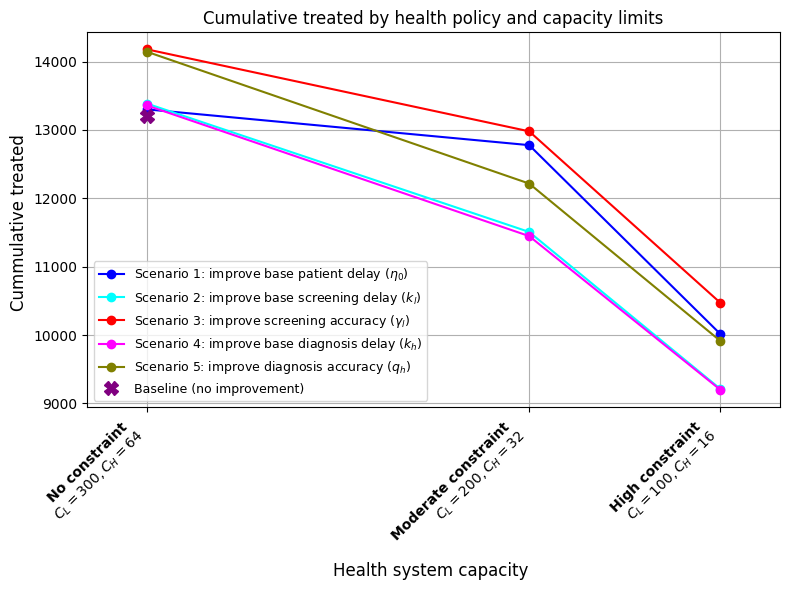

In [16]:
capacity_scenarios = ['No constraint \n' + r'$C_L = 300, C_H = 64$' , 'Moderate constraint \n' + r'$ C_L = 200, C_H = 32$', 'High constraint \n' + r'$ C_L = 100, C_H = 16$' ]
colors = {
    'Scenario 4: improve base diagnosis delay': 'magenta',
    'Scenario 5: improve diagnosis accuracy': 'olive',
    #'Scenario 8: improve diagnosis capacity': 'teal',
    
    # "Improve max diagnosis delay": 'lime',
    # "Improve max patient delay H" : 'green',
    
    'Scenario 2: improve base screening delay': 'cyan',
    'Scenario 3: improve screening accuracy': 'red',
    #'Scenario 5: improve screening capacity': 'yellow',
    # "Improve max screening delay": 'orangered',
    # "Improve max patient delay L" : 'black',

    'Scenario 1: improve base patient delay': 'blue',
    #'Scenario 2: improve care seeking proportion H': 'pink'
    #'Improve both': 'teal',
    
    #'Improve all': 'gray'
    
}

#['blue', 'orange', 'green', 'red', 'purple', 'cyan', 'hotpink', 'gray']
plt.figure(figsize=(8, 6))

# Plot each scenario line
for j, scenario_name in enumerate(improvements.keys()):
    subset = summary_df[summary_df["Scenario"] == scenario_name]
    subset_sorted = subset.sort_values(by="C_H", ascending=False)
    plt.plot(subset_sorted["C_H"], subset_sorted["Cumulative_cases"], marker='o', color=colors[scenario_name],
             label=f"{scenario_name} ({scenario_parameters[scenario_name]})")

    # special marker for Baseline when C_H == 500
    # if summary_df["C_H"] == 500:
    #     plt.plot(highlight["C_H"], highlight["Cumulative_cases"], marker='X', markersize=10,
    #          color='purple', linestyle='None', label="Baseline (no improvment)")
    
# highlight = summary_df[(summary_df["Scenario"] == "Scenario 8: improve diagnosis capacity") & (summary_df["C_H"] == 500)]
# if not highlight.empty:
plt.plot(64, Base_max_prevalence, marker='X', markersize=10,   color='purple', linestyle='None', label="Baseline (no improvement)")    

#plt.ylim([0, 3000])
#x_pos = np.arange(len(H_capacity_scenarios))
plt.xticks(ticks=H_capacity_scenarios, labels=capacity_scenarios, rotation=45, ha="right",  fontsize=10, fontweight='bold')
plt.xlim(max(H_capacity_scenarios)+5, min(H_capacity_scenarios)-5)
#plt.xticks(['500', 1500, 2500, 5000])
plt.xlabel("Health system capacity ", fontsize=12)
plt.ylabel("Cummulative treated ", fontsize=12)
plt.title("Cumulative treated by health policy and capacity limits", fontsize=12)
plt.legend(ncol=1, loc='lower left', fontsize=9)
plt.grid(True)

# ax = plt.gca()  # get current axes
# yticks = ax.get_yticks()
# ax.set_yticklabels([f'{tick/100:.0f}' for tick in yticks])

plt.tight_layout()
plt.show()

In [17]:
subset_sorted

,Scenario,C_H,Cumulative_cases
12,Scenario 5: improve diagnosis accuracy,64,14142.545242
13,Scenario 5: improve diagnosis accuracy,32,12214.944841
14,Scenario 5: improve diagnosis accuracy,16,9914.100910
